**Author:** Ashutosh Jayant  
**Project:** India State Competitiveness Index (ISCI)

# 06 - Exploratory Data Analysis

Research question: what does the data look like before we interpret it?
Reads the Version 1.0 outputs only. Every chart has a short observation below it.

## Setup

Load the Version 1.0 outputs (read only) and the scoring module, and make the figures
folder for this notebook.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# find the project root (the folder that has src/)
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src import scoring

fig_dir = root / "version2" / "figures" / "eda"
fig_dir.mkdir(parents=True, exist_ok=True)

# Version 1.0 outputs, read only
master = pd.read_csv(root / "data" / "processed" / "master_features.csv", index_col=0)
scores = pd.read_csv(root / "results" / "indicator_scores.csv", index_col=0)
dimensions = pd.read_csv(root / "results" / "dimension_scores.csv", index_col=0)
index = pd.read_csv(root / "results" / "competitiveness_index.csv", index_col=0)

# raw values of the 11 indicators (unemployment as the average used in Version 1.0)
raw = master.copy()
raw["unemployment_rate"] = master[["unemp_rural", "unemp_urban"]].mean(axis=1)
raw = raw[scoring.INDICATORS]

sns.set_theme(style="whitegrid")
print("raw:", raw.shape, "| scores:", scores.shape,
      "| dimensions:", dimensions.shape, "| index:", index.shape)

raw: (36, 11) | scores: (36, 11) | dimensions: (36, 2) | index: (36, 4)


## Summary statistics

For each of the 11 indicators: how many states have a value, the average, the spread
(standard deviation), the smallest and largest value, and the skew. Skew tells us if the
values are lopsided. A high skew means a few states have very large values.

In [2]:
summary = raw.describe().T[["count", "mean", "std", "min", "50%", "max"]]
summary["skew"] = raw.skew()
summary.round(2)

,count,mean,std,min,50%,max,skew
ger,36.0,74.83,15.43,44.70,73.95,108.70,0.16
life_expectancy,22.0,68.64,2.51,62.80,68.80,73.00,-0.25
unemployment_rate,35.0,51.91,24.73,13.50,47.00,110.50,0.54
cd_ratio,36.0,65.29,28.37,12.70,57.45,157.20,1.13
per_capita_power,34.0,1664.78,2395.41,328.90,1371.80,14563.80,5.00
td_losses,33.0,19.07,6.50,7.10,18.40,43.00,1.52
road_density,33.0,731.08,667.69,83.92,470.65,3402.97,2.31
factory_density,34.0,19.96,14.14,2.69,16.77,52.26,0.88
msme_density,34.0,5605.82,1687.04,2107.07,5423.51,9800.36,0.16
manufacturing_share,34.0,12.89,10.19,0.39,11.14,35.49,0.81


## Missing values

How much data is missing, and where. First by indicator, then by state.

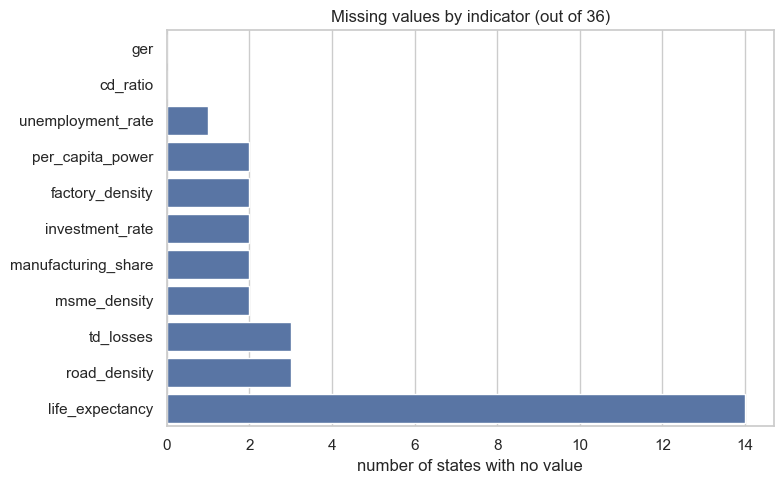

states with missing indicators:
entity
Dadra & Nagar Haveli and Daman & Diu    7
Lakshadweep                             6
Ladakh                                  4
Andaman & Nicobar Islands               3
Chandigarh                              1
Goa                                     1
Arunachal Pradesh                       1
Jammu & Kashmir                         1
Manipur                                 1
Meghalaya                               1
Mizoram                                 1
Nagaland                                1
Puducherry                              1
Sikkim                                  1
Tripura                                 1


In [3]:
missing = raw.isna().sum().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=missing.values, y=missing.index, color="#4c72b0")
plt.xlabel("number of states with no value")
plt.ylabel("")
plt.title("Missing values by indicator (out of 36)")
plt.tight_layout()
plt.savefig(fig_dir / "missing_by_indicator.png", dpi=150)
plt.show()

per_state = raw.isna().sum(axis=1)
print("states with missing indicators:")
print(per_state[per_state > 0].sort_values(ascending=False).to_string())

### Observation

Most of the missing data is in one indicator. Life expectancy is available for only 22
of 36 states, because it is published for the larger states only.

The other indicators are almost complete. At most they miss two or three small
territories.

The gaps are not spread evenly. They pile up in a few small union territories: Dadra &
Nagar Haveli and Daman & Diu (7 of 11 missing), Lakshadweep (6), Ladakh (4) and Andaman
& Nicobar (3). These are the same territories the index could not rank. The larger states
have full or nearly full data.

## Indicator distributions

The shape of each indicator across states. A histogram shows how many states fall in
each value range.

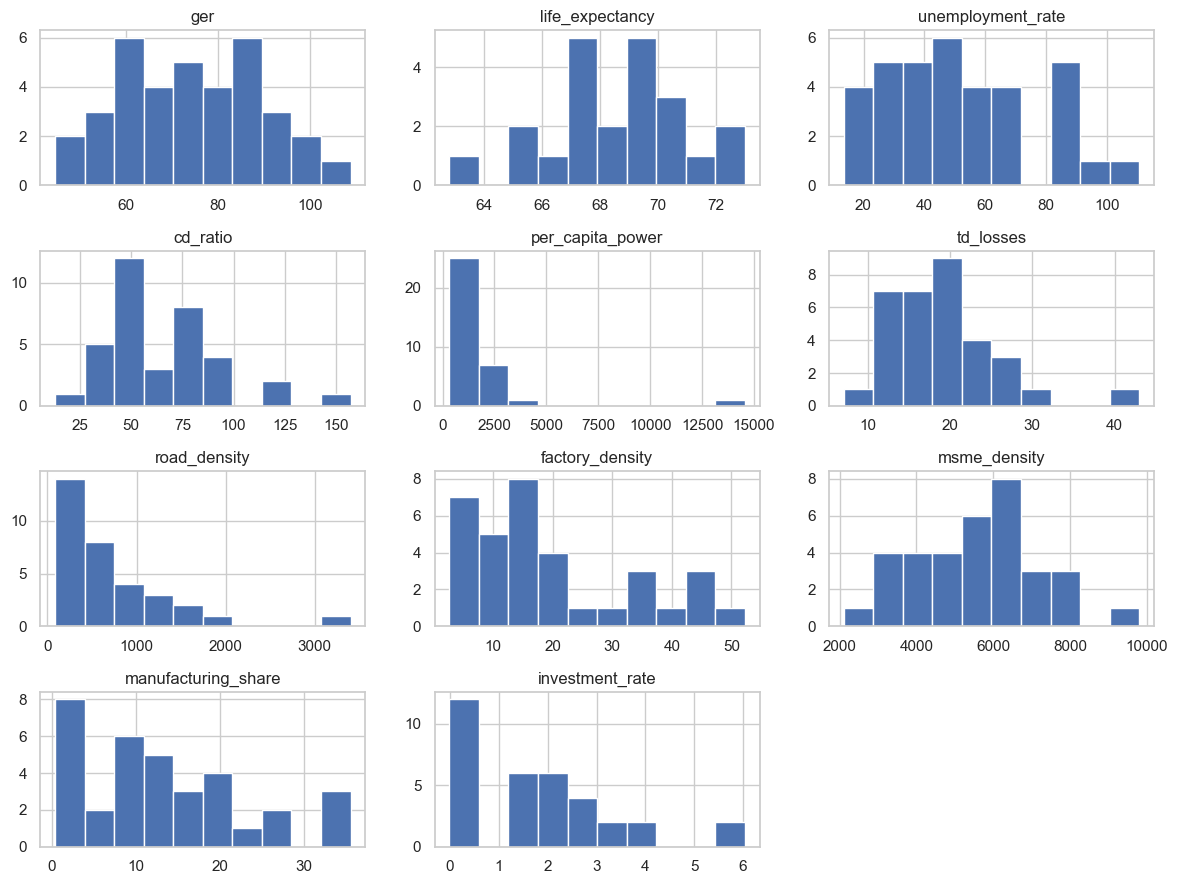

In [4]:
raw.hist(figsize=(12, 9), bins=10, color="#4c72b0", edgecolor="white")
plt.tight_layout()
plt.savefig(fig_dir / "indicator_distributions.png", dpi=150)
plt.show()

### Observation

Many indicators are lopsided. Per-capita power and road density are strongly
right-skewed: most states sit low, and a few states have very high values.

Unemployment, T&D losses, credit-deposit ratio, factory density and manufacturing share
also lean to the right, but less strongly.

A few indicators are close to even, such as gross enrolment ratio and MSME density. Life
expectancy is slightly left-skewed.

## Boxplots and outliers

A boxplot shows the middle range of each indicator and marks states that sit far outside
it. We use the normalized scores here so all indicators are on the same 0 to 1 scale.

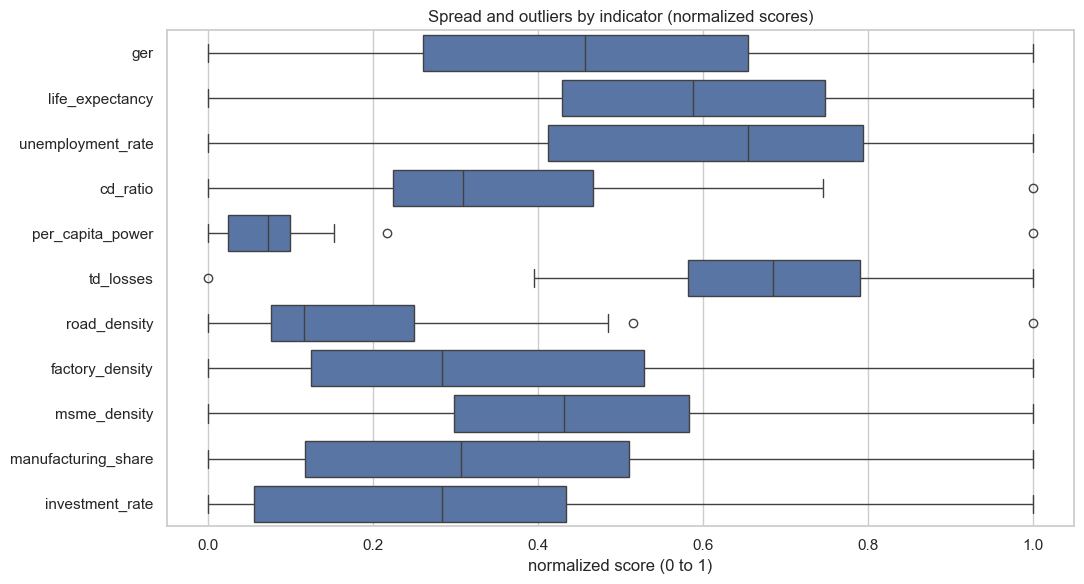

In [5]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=scores, orient="h", color="#4c72b0")
plt.xlabel("normalized score (0 to 1)")
plt.title("Spread and outliers by indicator (normalized scores)")
plt.tight_layout()
plt.savefig(fig_dir / "boxplots_outliers.png", dpi=150)
plt.show()

### Observation

On the same 0 to 1 scale, most indicators have a normal spread. Only a few states stand
out as outliers.

Andhra Pradesh is an outlier on credit-deposit ratio. Dadra & Nagar Haveli and Daman &
Diu, and Goa stand out on per-capita power. Arunachal Pradesh and Sikkim stand out on
road density, and Arunachal also on T&D losses.

These are mostly small states or union territories. A large value in a small place, like
power use per person or roads per person, can look extreme next to bigger states. The
values are real, not errors, so they are kept.

## Correlation between indicators

This shows which indicators rise and fall together. A value near +1 means two indicators
move the same way, near -1 means opposite, and near 0 means little link. We use the
normalized scores, where higher is better for every indicator.

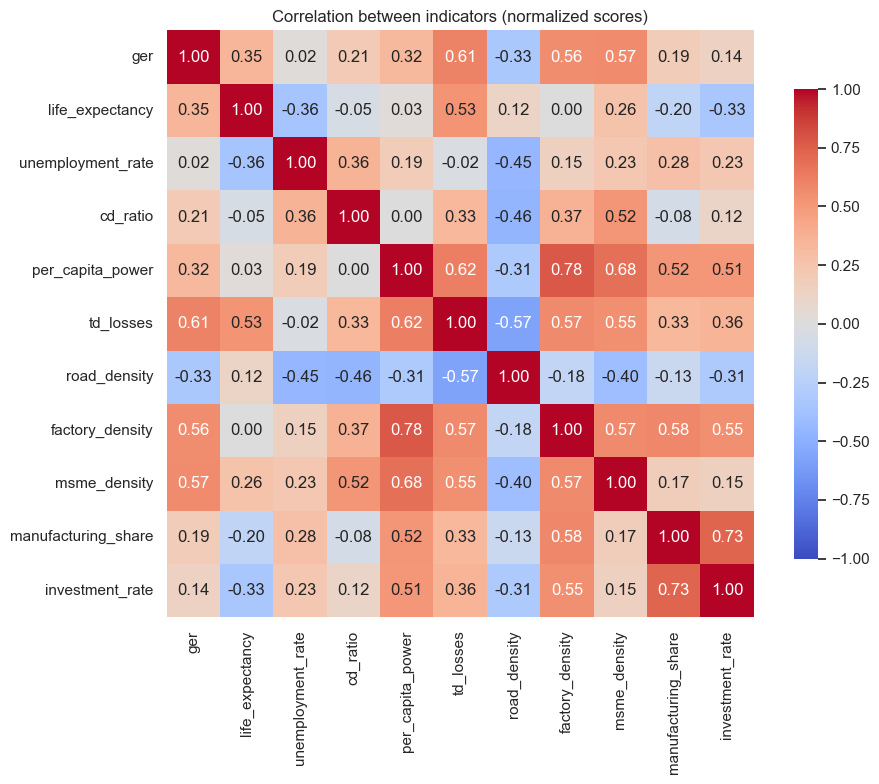

In [6]:
plt.figure(figsize=(10, 8))
corr = scores.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation between indicators (normalized scores)")
plt.tight_layout()
plt.savefig(fig_dir / "correlation_heatmap.png", dpi=150)
plt.show()

### Observation

Some indicators move together. Per-capita power, factory density and MSME density have
strong positive correlations, and manufacturing share and investment rate rise together
(0.73).

Road density has negative correlations with several indicators, such as T&D losses,
credit-deposit ratio and MSME density.

Most other pairs have weak links. The reasons behind these patterns are examined in the
later notebooks.

## Key relationships

A closer look at a few important pairs of indicators. Each dot is a state, and the line
shows the general trend.

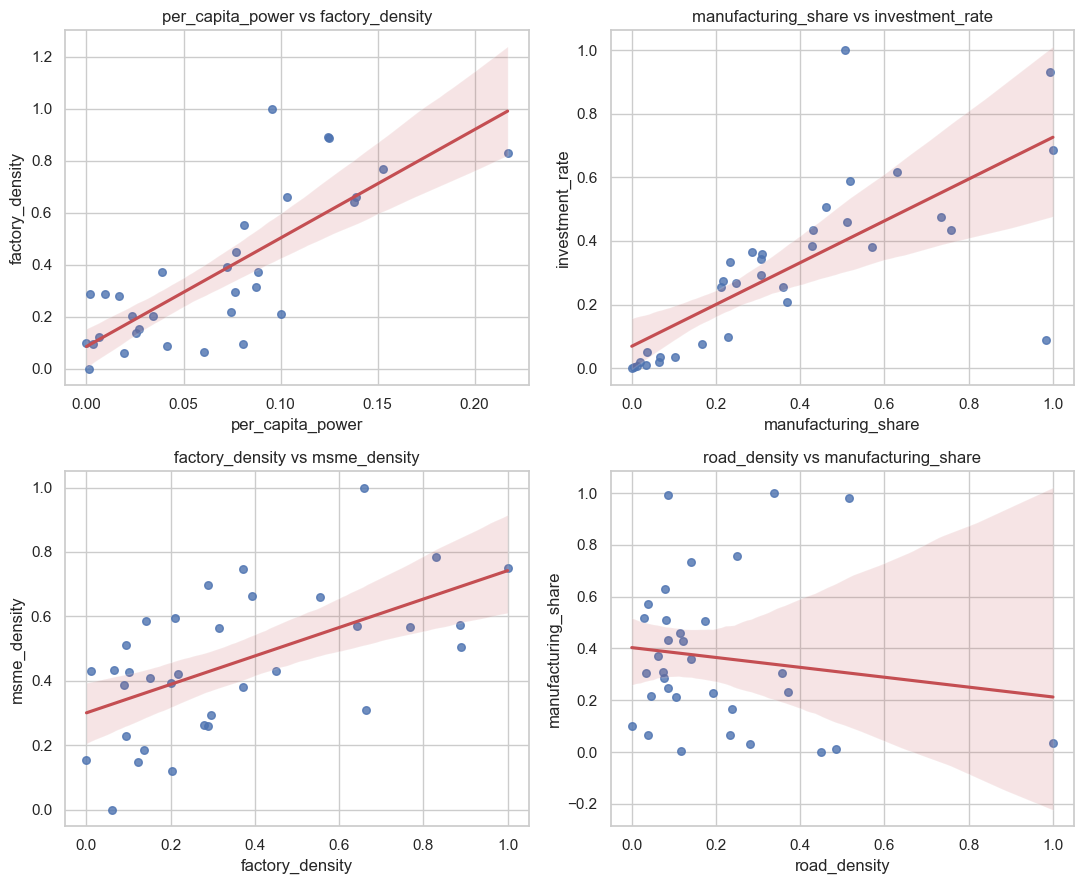

In [7]:
pairs = [
    ("per_capita_power", "factory_density"),
    ("manufacturing_share", "investment_rate"),
    ("factory_density", "msme_density"),
    ("road_density", "manufacturing_share"),
]

fig, axs = plt.subplots(2, 2, figsize=(11, 9))
for ax, (x, y) in zip(axs.flat, pairs):
    sns.regplot(x=scores[x], y=scores[y], ax=ax,
                scatter_kws={"s": 30, "color": "#4c72b0"},
                line_kws={"color": "#c44e52"})
    ax.set_title(f"{x} vs {y}")
plt.tight_layout()
plt.savefig(fig_dir / "key_scatter_plots.png", dpi=150)
plt.show()

### Observation

The scatter plots match the correlation grid.

Per-capita power and factory density rise together, and manufacturing share and
investment rate rise together. The dots follow an upward line in both.

Factory density and MSME density also move up together, though less tightly.

Road density and manufacturing share move in opposite directions. Why this happens is
examined in the later notebooks.

## Score distributions

The shape of the final competitiveness score and the two dimension scores across states.

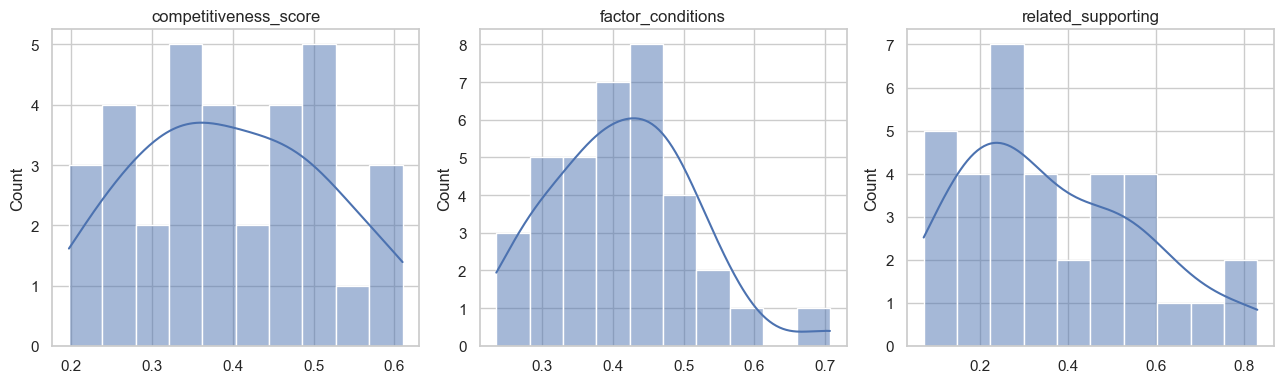

In [10]:
dist = pd.DataFrame({
    "competitiveness_score": index["competitiveness_score"],
    "factor_conditions": dimensions["factor_conditions"],
    "related_supporting": dimensions["related_supporting"],
})

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axs, dist.columns):
    sns.histplot(dist[col].dropna(), bins=10, kde=True, color="#4c72b0", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig(fig_dir / "score_distributions.png", dpi=150)
plt.show()

### Observation

The final score sits in a narrow band. Most states fall between 0.20 and 0.61, with an
average near 0.40.

The two dimensions have different spreads. Factor Conditions is tight, so states are
close on it. Related & Supporting Industries has a much wider spread, from 0.07 to 0.83.

What this difference means is examined in the later notebooks.

## Top 10 vs bottom 10

The average normalized score of the top 10 and bottom 10 states for each indicator. This
shows which indicators separate the strong states from the weak ones.

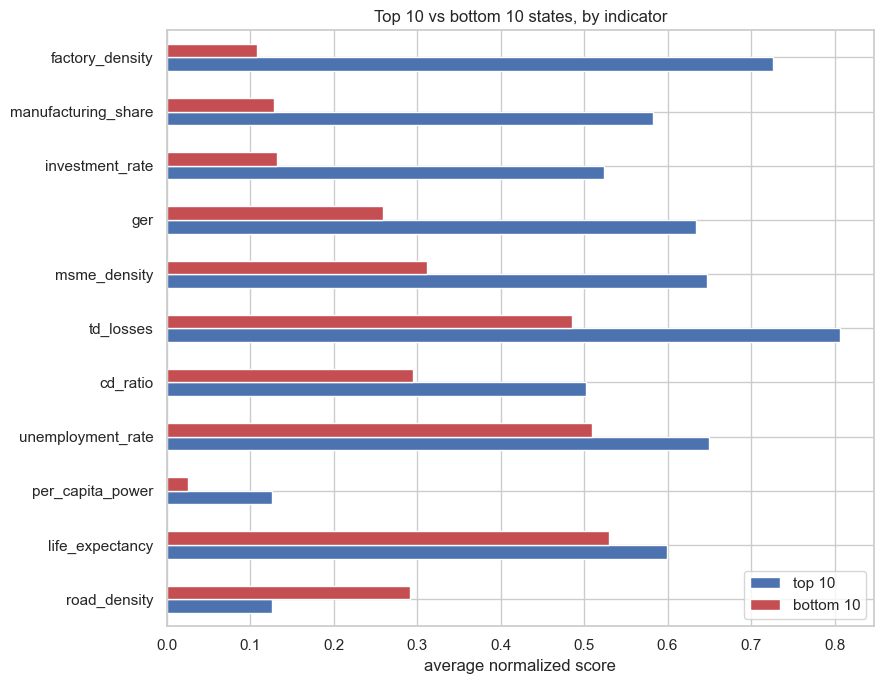

In [11]:
r = index["Rank"]
top = r[(r >= 1) & (r <= 10)].index
bottom = r[(r >= 24) & (r <= 33)].index

comp = pd.DataFrame({"top 10": scores.loc[top].mean(),
                     "bottom 10": scores.loc[bottom].mean()})
comp["gap"] = comp["top 10"] - comp["bottom 10"]
comp = comp.sort_values("gap")

comp[["top 10", "bottom 10"]].plot(kind="barh", figsize=(9, 7),
                                   color=["#4c72b0", "#c44e52"])
plt.xlabel("average normalized score")
plt.title("Top 10 vs bottom 10 states, by indicator")
plt.tight_layout()
plt.savefig(fig_dir / "top_vs_bottom.png", dpi=150)
plt.show()

### Observation

The largest differences between the top and bottom states are in the industrial
indicators: factory density, manufacturing share, investment rate and MSME density.

Gross enrolment ratio also shows a clear difference.

The gaps in life expectancy and per-capita power are small.

Road density is reversed: the bottom states have higher road density than the top states.
These differences are analysed in the following notebooks.

## Summary of findings

- The indicators use very different units, so they are put on the same scale before
  combining.
- Missing data is mostly in the small union territories and in life expectancy. The
  larger states have nearly full data.
- Many indicators are right-skewed, with a few states far above the rest.
- Some indicators have strong positive correlations (power, factory density, MSME
  density, manufacturing share, investment rate). Road density has negative correlations
  with several indicators.
- The final scores are close together. Factor Conditions has a narrow spread, and Related
  & Supporting Industries has a wide spread.
- The top and bottom states show the largest differences on the industrial indicators.
- The reasons behind these patterns are examined in Notebooks 07 onward.